## Step 6 & 8 — Results Analysis & Visualization

Full evaluation of both Keras and TFLite models. All plots saved for dissertation report.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import json
import os

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

%matplotlib inline

DATA_PATH    = '../data/processed/cwru_processed.npz'
KERAS_MODEL  = '../models/cae_model.h5'
TFLITE_INT8  = '../models/cae_quantized.tflite'
HISTORY_JSON = '../results/training_history.json'
BENCH_JSON   = '../results/benchmark.json'
PLOTS_DIR    = '../results/plots'
RESULT_DIR   = '../results'

os.makedirs(PLOTS_DIR, exist_ok=True)
print('Ready')


Ready


### 6.1 — Training history

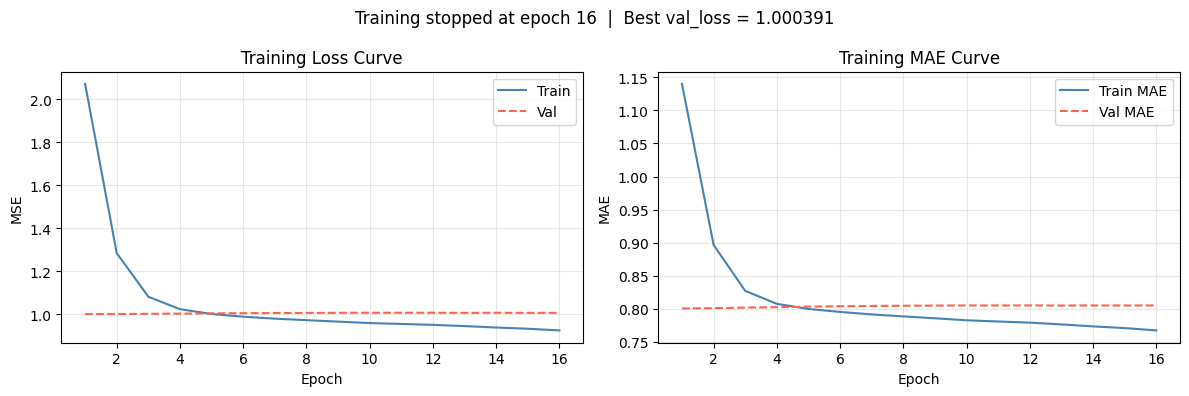

In [2]:
with open(HISTORY_JSON) as f:
    h = json.load(f)

epochs = range(1, len(h['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, h['loss'],     label='Train', color='steelblue')
axes[0].plot(epochs, h['val_loss'], label='Val',   color='tomato', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('Training Loss Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, h['mae'],     label='Train MAE', color='steelblue')
axes[1].plot(epochs, h['val_mae'], label='Val MAE',   color='tomato', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Training MAE Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Training stopped at epoch {len(epochs)}  |  Best val_loss = {min(h["val_loss"]):.6f}')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'training_loss.png'), dpi=150)
plt.show()

### 6.2 — Load data and run inference

In [3]:
data    = np.load(DATA_PATH, allow_pickle=True)
X_all   = data['X_raw'][..., np.newaxis].astype(np.float32)
y       = data['y_labels']
y_names = data['y_names']
y_bin   = (y > 0).astype(int)

print(f'Total samples : {len(X_all)}')
print(f'Normal        : {(y==0).sum()}')
print(f'Fault         : {(y!=0).sum()}')

Total samples : 4735
Normal        : 471
Fault         : 4264


In [4]:
# keras inference
model  = tf.keras.models.load_model(KERAS_MODEL)
recon  = model.predict(X_all, batch_size=64, verbose=1)
mse_k  = np.mean((X_all - recon)**2, axis=(1, 2))
print(f'Keras MSE computed. Shape: {mse_k.shape}')


74/74 [==============================] - 2s 26ms/step
Keras MSE computed. Shape: (4735,)


In [5]:
# tflite int8 inference
interp  = tf.lite.Interpreter(model_path=TFLITE_INT8)
interp.allocate_tensors()
in_idx  = interp.get_input_details()[0]['index']
out_idx = interp.get_output_details()[0]['index']

mse_tfl = []
for i in range(len(X_all)):
    s = X_all[i:i+1]
    interp.set_tensor(in_idx, s)
    interp.invoke()
    r = interp.get_tensor(out_idx)
    mse_tfl.append(float(np.mean((s - r)**2)))
    if (i+1) % 500 == 0:
        print(f'  {i+1}/{len(X_all)} done')

mse_tfl = np.array(mse_tfl)
print('TFLite MSE computed.')

  500/4735 done
  1000/4735 done
  1500/4735 done
  2000/4735 done
  2500/4735 done
  3000/4735 done
  3500/4735 done
  4000/4735 done
  4500/4735 done
TFLite MSE computed.


### 6.3 — Anomaly threshold and predictions

In [6]:
thresh_k   = np.percentile(mse_k[y==0],   95)
thresh_tfl = np.percentile(mse_tfl[y==0], 95)

y_pred_k   = (mse_k   > thresh_k).astype(int)
y_pred_tfl = (mse_tfl > thresh_tfl).astype(int)

print(f'Threshold Keras   : {thresh_k:.6f}')
print(f'Threshold TFLite  : {thresh_tfl:.6f}')

Threshold Keras   : 1.120975
Threshold TFLite  : 1.120976


### 6.4 — Classification metrics

In [7]:
def metrics_dict(y_true, y_pred, mse_scores):
    return {
        'f1'       : float(f1_score(y_true, y_pred, zero_division=0)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall'   : float(recall_score(y_true, y_pred, zero_division=0)),
        'auc_roc'  : float(roc_auc_score(y_true, mse_scores)),
        'cm'       : confusion_matrix(y_true, y_pred).tolist()
    }

m_keras = metrics_dict(y_bin, y_pred_k,   mse_k)
m_tfl   = metrics_dict(y_bin, y_pred_tfl, mse_tfl)

print(f'{"Metric":<12} {"Keras float32":>16} {"TFLite int8":>14}')
print('-' * 45)
for key in ['f1','precision','recall','auc_roc']:
    print(f'{key:<12} {m_keras[key]:>16.4f} {m_tfl[key]:>14.4f}')

Metric          Keras float32    TFLite int8
---------------------------------------------
f1                     0.9972         0.9972
precision              0.9944         0.9944
recall                 1.0000         1.0000
auc_roc                1.0000         1.0000


In [8]:
print('--- Keras float32 ---')
print(classification_report(y_bin, y_pred_k, target_names=['Normal','Fault']))
print('--- TFLite int8 ---')
print(classification_report(y_bin, y_pred_tfl, target_names=['Normal','Fault']))

--- Keras float32 ---
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97       471
       Fault       0.99      1.00      1.00      4264

    accuracy                           0.99      4735
   macro avg       1.00      0.97      0.99      4735
weighted avg       0.99      0.99      0.99      4735

--- TFLite int8 ---
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97       471
       Fault       0.99      1.00      1.00      4264

    accuracy                           0.99      4735
   macro avg       1.00      0.97      0.99      4735
weighted avg       0.99      0.99      0.99      4735



### 6.5 — Plots

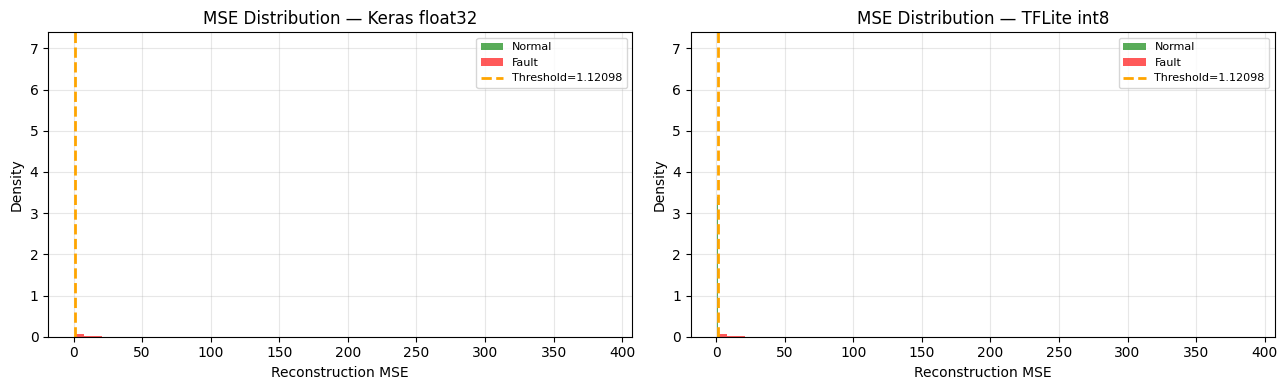

In [9]:
# MSE distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, mse, thresh, title in [
    (axes[0], mse_k,   thresh_k,   'Keras float32'),
    (axes[1], mse_tfl, thresh_tfl, 'TFLite int8')
]:
    ax.hist(mse[y==0], bins=60, alpha=0.65, color='green', label='Normal', density=True)
    ax.hist(mse[y!=0], bins=60, alpha=0.65, color='red',   label='Fault',  density=True)
    ax.axvline(thresh, color='orange', linestyle='--', linewidth=2,
                label=f'Threshold={thresh:.5f}')
    ax.set_xlabel('Reconstruction MSE')
    ax.set_ylabel('Density')
    ax.set_title(f'MSE Distribution — {title}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'mse_distribution.png'), dpi=150)
plt.show()

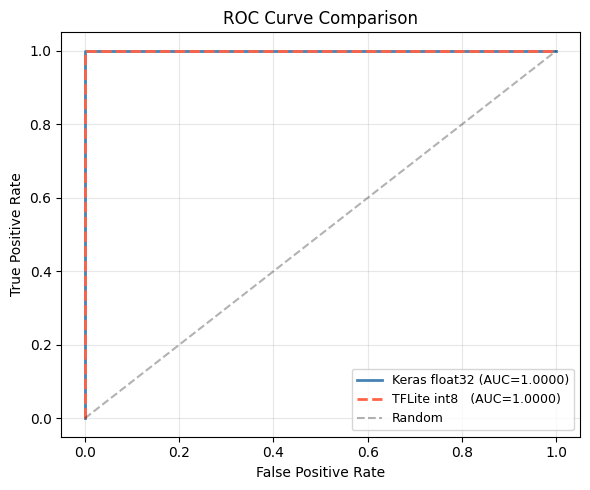

In [10]:
# ROC curves — both models on same plot
fpr_k,   tpr_k,   _ = roc_curve(y_bin, mse_k)
fpr_tfl, tpr_tfl, _ = roc_curve(y_bin, mse_tfl)

plt.figure(figsize=(6, 5))
plt.plot(fpr_k,   tpr_k,   label=f'Keras float32 (AUC={m_keras["auc_roc"]:.4f})', color='steelblue', linewidth=2)
plt.plot(fpr_tfl, tpr_tfl, label=f'TFLite int8   (AUC={m_tfl["auc_roc"]:.4f})',   color='tomato',    linewidth=2, linestyle='--')
plt.plot([0,1],[0,1], 'k--', alpha=0.3, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'roc_curve.png'), dpi=150)
plt.show()

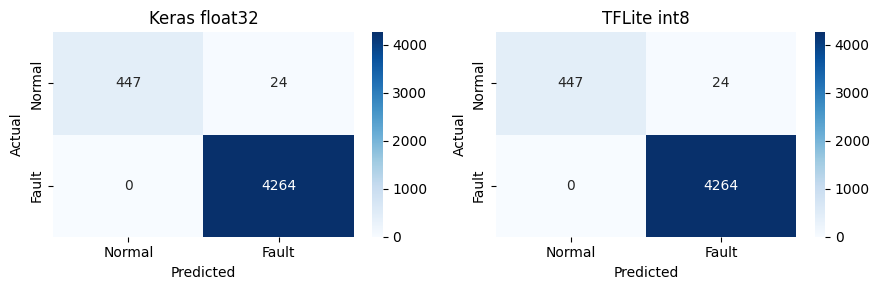

In [11]:
# confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, cm, title in [
    (axes[0], np.array(m_keras['cm']), 'Keras float32'),
    (axes[1], np.array(m_tfl['cm']),   'TFLite int8')
]:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal','Fault'], yticklabels=['Normal','Fault'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

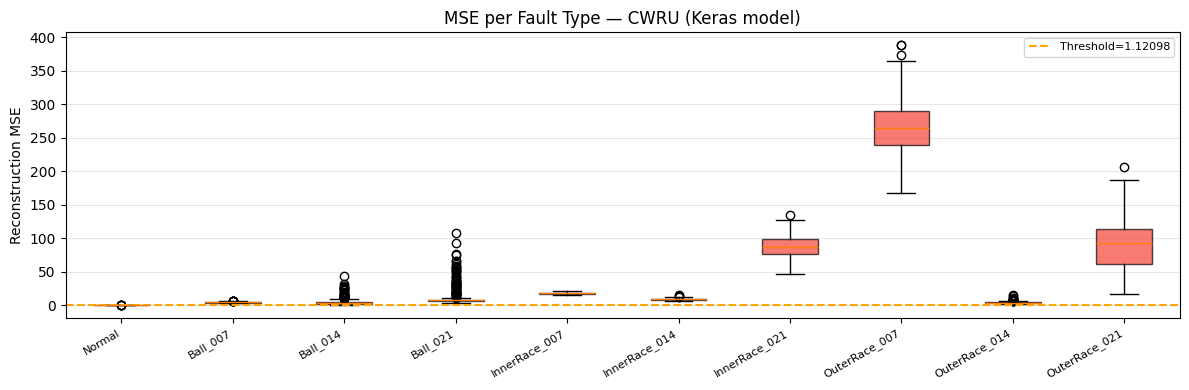

In [12]:
# per-fault MSE box plot
unique = list(dict.fromkeys(y_names))
groups = [mse_k[y_names == n] for n in unique]

fig, ax = plt.subplots(figsize=(12, 4))
bp = ax.boxplot(groups, patch_artist=True, widths=0.5)
for patch, name in zip(bp['boxes'], unique):
    patch.set_facecolor('#4CAF50' if name == 'Normal' else '#F44336')
    patch.set_alpha(0.7)

ax.axhline(thresh_k, color='orange', linestyle='--', linewidth=1.5, label=f'Threshold={thresh_k:.5f}')
ax.set_xticks(range(1, len(unique)+1))
ax.set_xticklabels(unique, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Reconstruction MSE')
ax.set_title('MSE per Fault Type — CWRU (Keras model)')
ax.legend(fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'per_fault_mse.png'), dpi=150)
plt.show()

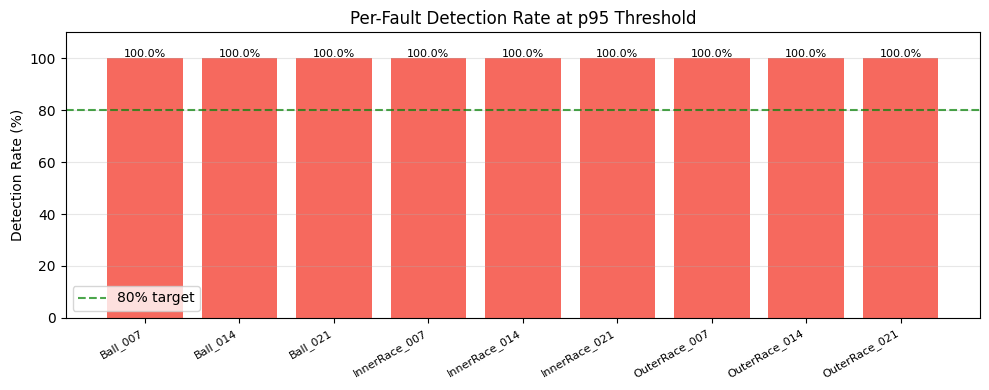

In [13]:
# per-fault detection rate bar chart
fault_names = [n for n in unique if n != 'Normal']
detect_rates = []
for name in fault_names:
    mask = (y_names == name)
    rate = y_pred_k[mask].mean() * 100
    detect_rates.append(rate)

plt.figure(figsize=(10, 4))
bars = plt.bar(fault_names, detect_rates, color='#F44336', alpha=0.8)
for bar, v in zip(bars, detect_rates):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f'{v:.1f}%', ha='center', fontsize=8)
plt.axhline(80, color='green', linestyle='--', alpha=0.7, label='80% target')
plt.xticks(rotation=30, ha='right', fontsize=8)
plt.ylabel('Detection Rate (%)')
plt.title('Per-Fault Detection Rate at p95 Threshold')
plt.ylim(0, 110)
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'detection_rate.png'), dpi=150)
plt.show()

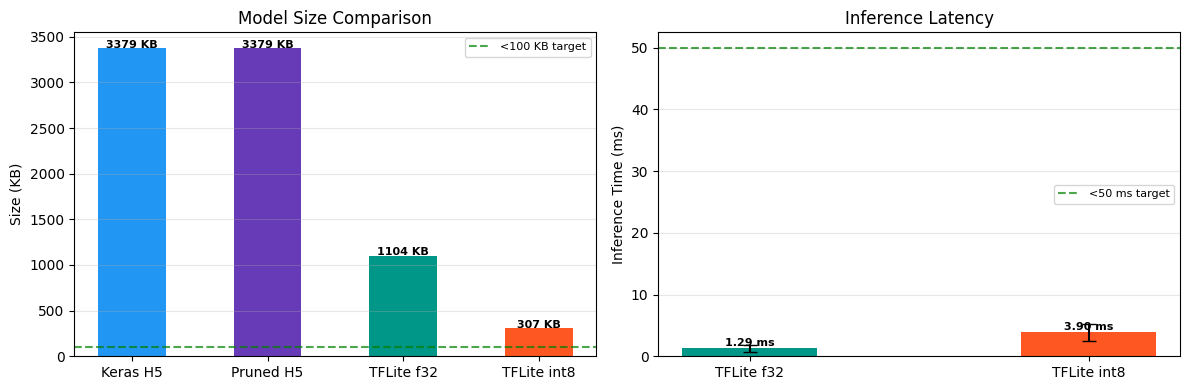

In [14]:
# load benchmark and plot model sizes + latency
with open(BENCH_JSON) as f:
    bench = json.load(f)

size_labels = ['Keras H5', 'TFLite f32', 'TFLite int8']
size_vals   = [bench['keras_kb'], bench['f32_kb'], bench['int8_kb']]
if bench.get('pruned_kb', 0) > 0:
    size_labels.insert(1, 'Pruned H5')
    size_vals.insert(1, bench['pruned_kb'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# sizes
colors = ['#2196F3','#673AB7','#009688','#FF5722'][:len(size_labels)]
b1 = axes[0].bar(size_labels, size_vals, color=colors, width=0.5)
for bar, v in zip(b1, size_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                  f'{v:.0f} KB', ha='center', fontsize=8, fontweight='bold')
axes[0].axhline(100, color='green', linestyle='--', alpha=0.7, label='<100 KB target')
axes[0].set_ylabel('Size (KB)')
axes[0].set_title('Model Size Comparison')
axes[0].legend(fontsize=8)
axes[0].grid(True, axis='y', alpha=0.3)

# latency
b2 = axes[1].bar(['TFLite f32','TFLite int8'],
                   [bench['f32_ms'], bench['int8_ms']],
                   yerr=[bench['f32_std_ms'], bench['int8_std_ms']],
                   capsize=5, color=['#009688','#FF5722'], width=0.4)
for bar, v in zip(b2, [bench['f32_ms'], bench['int8_ms']]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                  f'{v:.2f} ms', ha='center', fontsize=8, fontweight='bold')
axes[1].axhline(50, color='green', linestyle='--', alpha=0.7, label='<50 ms target')
axes[1].set_ylabel('Inference Time (ms)')
axes[1].set_title('Inference Latency')
axes[1].legend(fontsize=8)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'model_sizes_latency.png'), dpi=150)
plt.show()

### 6.6 — Save final metrics

In [15]:
final_metrics = {
    'threshold_percentile': 95,
    'keras_float32'       : m_keras,
    'tflite_int8'         : m_tfl
}
with open(os.path.join(RESULT_DIR, 'metrics.json'), 'w') as f:
    json.dump(final_metrics, f, indent=2)
print('Saved: metrics.json')

Saved: metrics.json


### Final Summary

In [16]:
print('=' * 50)
print('  DISSERTATION RESULTS SUMMARY')
print('=' * 50)
print(f'  Detection (Keras float32)')
print(f'    F1-Score  : {m_keras["f1"]:.4f}')
print(f'    Precision : {m_keras["precision"]:.4f}')
print(f'    Recall    : {m_keras["recall"]:.4f}')
print(f'    AUC-ROC   : {m_keras["auc_roc"]:.4f}')
print(f'\n  Detection (TFLite int8)')
print(f'    F1-Score  : {m_tfl["f1"]:.4f}')
print(f'    AUC-ROC   : {m_tfl["auc_roc"]:.4f}')
print(f'\n  Model Compression')
print(f'    Keras H5  : {bench["keras_kb"]:.0f} KB')
print(f'    TFLite int8: {bench["int8_kb"]:.0f} KB  ({bench["compression"]:.1f}x smaller)')
print(f'    Speed-up  : {bench["speedup"]:.1f}x faster (float32 → int8)')
print('=' * 50)
print('All plots saved to results/plots/')

  DISSERTATION RESULTS SUMMARY
  Detection (Keras float32)
    F1-Score  : 0.9972
    Precision : 0.9944
    Recall    : 1.0000
    AUC-ROC   : 1.0000

  Detection (TFLite int8)
    F1-Score  : 0.9972
    AUC-ROC   : 1.0000

  Model Compression
    Keras H5  : 3379 KB
    TFLite int8: 307 KB  (11.0x smaller)
    Speed-up  : 0.3x faster (float32 → int8)
All plots saved to results/plots/
